In [1]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import warnings

# Ignore matplotlib warnings
warnings.filterwarnings('ignore')

In [2]:
# Separate diamond multiple results file into specific results file
def separate_diamond_results(filename, keyword, output_dir):
    df = pd.read_csv(filename)
    df = df[(df['query'].str.contains(keyword)) | (df['query_number'] == 0)]  # Keep queries of interest and warm-up query
    df.to_csv(output_dir, index=False)

# Separate diamond results file into multiple files
"""
for k in (10, 100, 1000):
    separate_diamond_results('Diamond/diamond_shortest_k_walks_bfs.csv', f'SHORTEST {k} WALKS', f'Diamond/diamond_shortest_{k}_walks_bfs.csv')
    separate_diamond_results('Diamond/diamond_shortest_k_trails_bfs.csv', f'SHORTEST {k} TRAILS', f'Diamond/diamond_shortest_{k}_trails_bfs.csv')
    separate_diamond_results('Diamond/diamond_check_shortest_k_walks_bfs.csv', f'SHORTEST {k} WALKS', f'Diamond/diamond_check_shortest_{k}_walks_bfs.csv')
    separate_diamond_results('Diamond/diamond_check_shortest_k_trails_bfs.csv', f'SHORTEST {k} TRAILS', f'Diamond/diamond_check_shortest_{k}_trails_bfs.csv')
for k in range(1, 6):
    separate_diamond_results('Diamond/diamond_shortest_k_groups_walks_bfs.csv', f'SHORTEST {k} GROUPS WALKS', f'Diamond/diamond_shortest_{k}_groups_walks_bfs.csv')
    separate_diamond_results('Diamond/diamond_shortest_k_groups_trails_bfs.csv', f'SHORTEST {k} GROUPS TRAILS', f'Diamond/diamond_shortest_{k}_groups_trails_bfs.csv')
    separate_diamond_results('Diamond/diamond_check_shortest_k_groups_walks_bfs.csv', f'SHORTEST {k} GROUPS WALKS', f'Diamond/diamond_check_shortest_{k}_groups_walks_bfs.csv')
    separate_diamond_results('Diamond/diamond_check_shortest_k_groups_trails_bfs.csv', f'SHORTEST {k} GROUPS TRAILS', f'Diamond/diamond_check_shortest_{k}_groups_trails_bfs.csv')
"""
print()

In [3]:
# Process raw time values from experiments
def process_time(df, time_var, time_limit):
    filtered_df = df[df['status'] == 'OK']  # Filter out TIMEOUTS and ERRORS
    filtered_df[time_var] = filtered_df[time_var].apply(lambda t: min(t, time_limit))  # Time is at most time limit
    return filtered_df

# Process raw data for Pokec experiments
def process_pokec(df):
    max_len = min(len(df), 12)
    df = df.iloc[:max_len, :]  # Remove extra rows
    df['n'] = list(range(1, max_len + 1))  # Add 'n' value to each row (upper bound for path length)
    return df

# Process raw data for Diamond experiments
def process_diamond(df):
    df = df.iloc[1:, :]  # Remove warmup row
    max_len = min(len(df), 40)
    df = df.iloc[:max_len, :]  # Remove extra rows
    df['n'] = list(range(1, max_len + 1))  # Add 'n' value to each row (number of diamonds)
    return df

# Filter rows to create a cleaner representation
def create_interval(df, step):
    max_idx = len(df)
    middle_points = []
    if step < max_idx:
        middle_points = list(range(step, max_idx, step))
    chosen_points = [1] + middle_points + [max_idx]
    return df[df.n.isin(chosen_points)]

In [4]:
# Create line plots
def generate_line_plots(parameter, group_filenames, data_func, labels, values, settings):
    # Prepare multiple line plots
    fig, axes = plt.subplots(1, len(group_filenames), sharey=values['share_y'], figsize=settings['figsize']) # Default Size: (6.4, 4.8)
    plt.subplots_adjust(wspace=0.1)

    # Support single plots
    if len(group_filenames) == 1:
        axes = [axes]

    # Title & Labels
    #fig.suptitle(labels['sup_title'], fontsize=12, fontweight='bold')
    #fig.supxlabel(labels['axes'][0], x=0.52, y=-0.05)
    axes[0].set_ylabel(labels['axes'][1])

    # Legend
    marker_symbols = ['o', 'v', 'X', 'P', '^', 'd', 'D', 's', 'p']
    marker_function = lambda m,c: mlines.Line2D([], [], marker=m, markersize=10, markeredgecolor='0.15', markerfacecolor=c, linestyle='', alpha=0.7)
    legend_handles = [marker_function(marker_symbols[color_idx], sb.color_palette()[color_idx]) for color_idx in settings['legend_colors']]
    fig.legend(handles=legend_handles,
               labels=labels['legend'],
               ncol=settings['legend_cols'],
               loc='upper center',
               bbox_to_anchor=settings['legend_anchor'],
               frameon=False,
               columnspacing=0.8,
               handlelength=1.0,
               handletextpad=0.5)

    # Create each line plot
    for idx, group in enumerate(group_filenames):
        # Load data from CSV files
        main_data = pd.DataFrame({parameter: pd.Series(dtype='int'),
                                 'n': pd.Series(dtype='int'),
                                 'engine': pd.Series(dtype='int')})
        for engine_idx, filename in enumerate(group):
            df = pd.read_csv(filename)
            df = data_func(df)  # Process raw data
            df = process_time(df, parameter, 60000)  # Process time values
            df['engine'] = engine_idx  # Add engine identifier
            if values['data_interval'] is not None:  # Create data interval for a more clean plot
                df = create_interval(df, values['data_interval'])
            main_data = pd.concat([main_data, df], ignore_index=True, sort=False)

        # Generate line plot from data
        colors = [sb.color_palette()[color_idx] for color_idx in values['colors'][idx]]
        chosen_markers = [marker_symbols[marker_idx] for marker_idx in values['colors'][idx]]
        g = sb.lineplot(x='n', y=parameter, data=main_data, hue='engine', style='engine',
                        markers=chosen_markers, markersize=8,
                        ax=axes[idx], legend=None, palette=colors, alpha=0.7)
        g.set(xlabel=None)

        # Visualization settings

        # Title
        axes[idx].set_title(labels['sub_titles'][idx], fontsize=10)

        # X Axis
        x_ticks = values['x_ticks']
        axes[idx].set_xticks(x_ticks)

        # Y Axis
        axes[idx].set_yscale(values['scale'])
        axes[idx].minorticks_off()
        axes[idx].grid(axis='y', linestyle='--')

    # Save image
    if settings['export']:
        plt.savefig(settings['output_filename'], bbox_inches='tight')

    # Display
    plt.show()

In [5]:
# Global settings
global_scale = 'log'  # Y axis scale, can be 'log' or 'linear'

# Engine names

# PG1: Neo4j
# PG2: Kuzu
# PG3: NebulaGraph
# S1: Jena
# S2: Virtuoso
# S3: Blazegraph

**Pokec Shortest K**

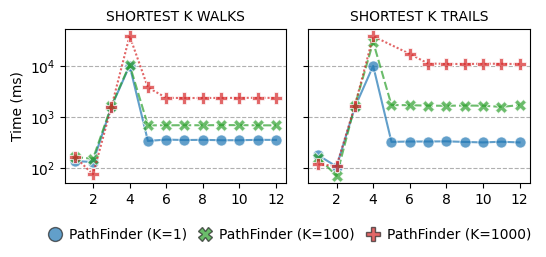

In [6]:
var = 'enum_time_ms'
names = ['PathFinder (K=1)',
         'PathFinder (K=100)',
         'PathFinder (K=1000)']

# SHORTEST K WALKS
files_a = ['Pokec/pokec_any_shortest_walks_bfs.csv',
           'Pokec/pokec_shortest_100_walks_bfs.csv',
           'Pokec/pokec_shortest_1000_walks_bfs.csv']
colors_a = [0, 2, 3]

# SHORTEST K TRAILS
files_b = ['Pokec/pokec_any_trails_bfs.csv',
           'Pokec/pokec_shortest_100_trails_bfs.csv',
           'Pokec/pokec_shortest_1000_trails_bfs.csv']
colors_b = colors_a

# Create line plots
sections = [files_a, files_b]
plot_labels = {'sup_title': 'POKEC SHORTEST K',
               'sub_titles': ('SHORTEST K WALKS', 'SHORTEST K TRAILS'),
               'axes': ('n', 'Time (ms)'),
               'legend': names}
value_settings = {'scale': global_scale,
                  'share_y': True,
                  'data_interval': None,
                  'x_ticks': [2, 4, 6, 8, 10, 12],
                  'colors': [colors_a, colors_b]}
general_settings = {'legend_cols': 3,
                    'legend_colors': [0, 2, 3],
                    'figsize': (6, 2),
                    'legend_anchor': (0.5, -0.05),
                    'export': True,
                    'output_filename': 'pokec_shortest_k_clean.pdf'}
generate_line_plots(var, sections, process_pokec, plot_labels, value_settings, general_settings)

**Pokec Shortest K Groups**

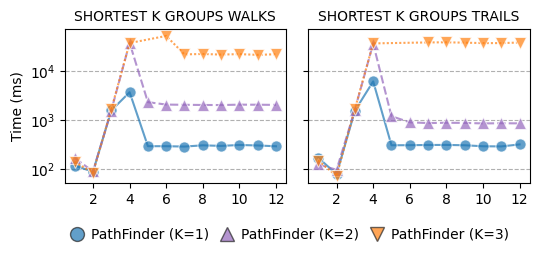

In [10]:
var = 'enum_time_ms'
names = ['PathFinder (K=1)',
         'PathFinder (K=2)',
         'PathFinder (K=3)']

# SHORTEST K GROUPS WALKS
files_a = ['Pokec/pokec_shortest_1_groups_walks_bfs.csv',
           'Pokec/pokec_shortest_2_groups_walks_bfs.csv',
           'Pokec/pokec_shortest_3_groups_walks_bfs.csv']
colors_a = [0, 4, 1]

# SHORTEST K GROUPS TRAILS
files_b = ['Pokec/pokec_shortest_1_groups_trails_bfs.csv',
           'Pokec/pokec_shortest_2_groups_trails_bfs.csv',
           'Pokec/pokec_shortest_3_groups_trails_bfs.csv',]
colors_b = colors_a

# Create line plots
sections = [files_a, files_b]
plot_labels = {'sup_title': 'POKEC SHORTEST K GROUPS',
               'sub_titles': ('SHORTEST K GROUPS WALKS', 'SHORTEST K GROUPS TRAILS'),
               'axes': ('n', 'Time (ms)'),
               'legend': names}
value_settings = {'scale': global_scale,
                  'share_y': True,
                  'data_interval': None,
                  'x_ticks': [2, 4, 6, 8, 10, 12],
                  'colors': [colors_a, colors_b]}
general_settings = {'legend_cols': 3,
                    'legend_colors': [0, 4, 1],
                    'figsize': (6, 2),
                    'legend_anchor': (0.5, -0.05),
                    'export': True,
                    'output_filename': 'pokec_shortest_k_groups_clean.pdf'}
generate_line_plots(var, sections, process_pokec, plot_labels, value_settings, general_settings)

**Diamond Shortest K**

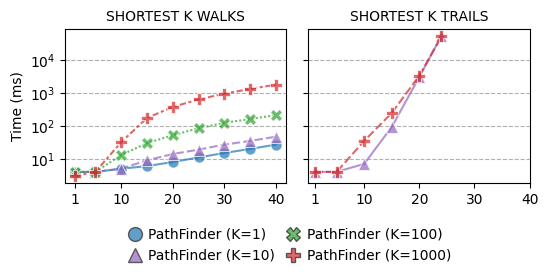

In [8]:
var = 'enum_time_ms'
names = ['PathFinder (K=1)',
         'PathFinder (K=10)',
         'PathFinder (K=100)',
         'PathFinder (K=1000)']

# SHORTEST K WALKS
files_a = ['Diamond/diamond_any_shortest_walks_bfs.csv',
           'Diamond/diamond_shortest_10_walks_bfs.csv',
           'Diamond/diamond_shortest_100_walks_bfs.csv',
           'Diamond/diamond_shortest_1000_walks_bfs.csv']
colors_a = [0, 4, 2, 3]

# SHORTEST K TRAILS
files_b = ['Diamond/diamond_shortest_10_trails_bfs.csv',
           'Diamond/diamond_shortest_1000_trails_bfs.csv']
colors_b = [4, 3]

# Create line plots
sections = [files_a, files_b]
plot_labels = {'sup_title': 'DIAMOND SHORTEST K',
               'sub_titles': ('SHORTEST K WALKS', 'SHORTEST K TRAILS'),
               'axes': ('n', 'Time (ms)'),
               'legend': names}
value_settings = {'scale': global_scale,
                  'share_y': True,
                  'data_interval': 5,
                  'x_ticks': [1, 10, 20, 30, 40],
                  'colors': [colors_a, colors_b]}
general_settings = {'legend_cols': 2,
                    'legend_colors': [0, 4, 2, 3],
                    'figsize': (6, 2),
                    'legend_anchor': (0.5, -0.05),
                    'export': True,
                    'output_filename': 'diamond_shortest_k_clean.pdf'}
generate_line_plots(var, sections, process_diamond, plot_labels, value_settings, general_settings)

**Diamond Shortest K Groups**

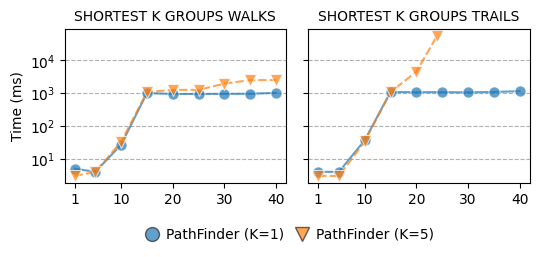

In [9]:
var = 'enum_time_ms'
names = ['PathFinder (K=1)',
         'PathFinder (K=5)']

# SHORTEST K GROUPS WALKS
files_a = ['Diamond/diamond_shortest_1_groups_walks_bfs.csv',
           'Diamond/diamond_shortest_5_groups_walks_bfs.csv']
colors_a = [0, 1]

# SHORTEST K GROUPS TRAILS
files_b = ['Diamond/diamond_shortest_1_groups_trails_bfs.csv',
           'Diamond/diamond_shortest_5_groups_trails_bfs.csv',]
colors_b = colors_a

# Create line plots
sections = [files_a, files_b]
plot_labels = {'sup_title': 'DIAMOND SHORTEST K GROUPS',
               'sub_titles': ('SHORTEST K GROUPS WALKS', 'SHORTEST K GROUPS TRAILS'),
               'axes': ('n', 'Time (ms)'),
               'legend': names}
value_settings = {'scale': global_scale,
                  'share_y': True,
                  'data_interval': 5,
                  'x_ticks': [1, 10, 20, 30, 40],
                  'colors': [colors_a, colors_b]}
general_settings = {'legend_cols': 2,
                    'legend_colors': [0, 1],
                    'figsize': (6, 2),
                    'legend_anchor': (0.5, -0.05),
                    'export': True,
                    'output_filename': 'diamond_shortest_k_groups_clean.pdf'}
generate_line_plots(var, sections, process_diamond, plot_labels, value_settings, general_settings)